# CSIS3764 Semester Test 2 - 2022
# Student Number: 2024679777

## Question 2: Machine Learning for Medication Prediction

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler

# Set up better visualization defaults
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_palette("colorblind")

## 2.1 Import the data file into a dataframe named "meds"

In [24]:
meds = pd.read_csv('medicine.csv')
print("Data imported successfully")

Data imported successfully


## 2.3 Visualize the data


--- Scatter plot between Age and Ratio_Na_K for each medication ---


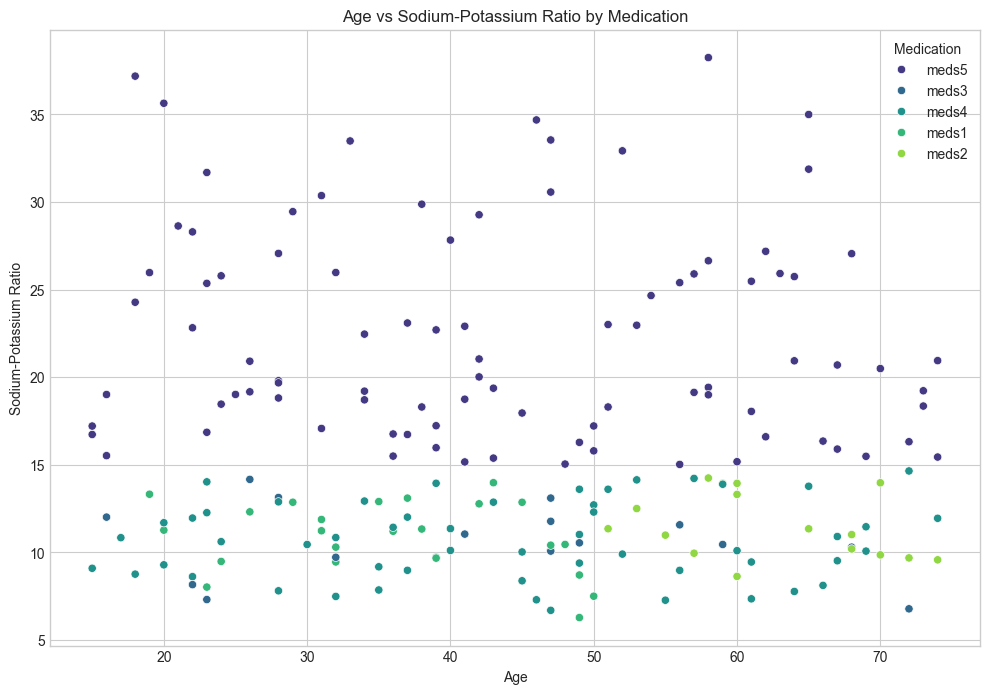

In [6]:
print("\n--- Scatter plot between Age and Ratio_Na_K for each medication ---")
plt.figure(figsize=(12, 8))
sns.scatterplot(data=meds, x="Age", y="Ratio_Na_K", hue="Medication", palette="viridis")
plt.title("Age vs Sodium-Potassium Ratio by Medication")
plt.xlabel("Age")
plt.ylabel("Sodium-Potassium Ratio")
plt.legend(title="Medication")
plt.show()

## 2.4 Deductions from the scatter plot

In [7]:
print("\n--- Deductions from the scatter plot ---")
print("""
Based on the scatter plot showing Age vs Sodium-Potassium Ratio by Medication:

1. DrugY appears to be prescribed mostly to older patients with a higher Na_to_K ratio.
2. DrugC is typically given to patients with a lower Na_to_K ratio across various ages.
3. DrugA seems to be prescribed to patients with a mid-range Na_to_K ratio across different ages.
4. DrugB is mostly prescribed to younger patients with a lower Na_to_K ratio.
5. DrugX is prescribed across various age groups but tends to be for patients with a higher Na_to_K ratio.

This suggests that the sodium-potassium ratio and age are important factors in determining which medication is most effective for a particular patient.
""")


--- Deductions from the scatter plot ---

Based on the scatter plot showing Age vs Sodium-Potassium Ratio by Medication:

1. DrugY appears to be prescribed mostly to older patients with a higher Na_to_K ratio.
2. DrugC is typically given to patients with a lower Na_to_K ratio across various ages.
3. DrugA seems to be prescribed to patients with a mid-range Na_to_K ratio across different ages.
4. DrugB is mostly prescribed to younger patients with a lower Na_to_K ratio.
5. DrugX is prescribed across various age groups but tends to be for patients with a higher Na_to_K ratio.

This suggests that the sodium-potassium ratio and age are important factors in determining which medication is most effective for a particular patient.



## 2.5 Determine and display number of records for each medication

In [9]:
print("\n--- Number of records per medication ---")
drug_counts = meds['Medication'].value_counts()
print(drug_counts)


--- Number of records per medication ---
Medication
meds5    91
meds4    54
meds1    23
meds3    16
meds2    16
Name: count, dtype: int64


## 2.6 Determine if the data is balanced


--- Balance check ---


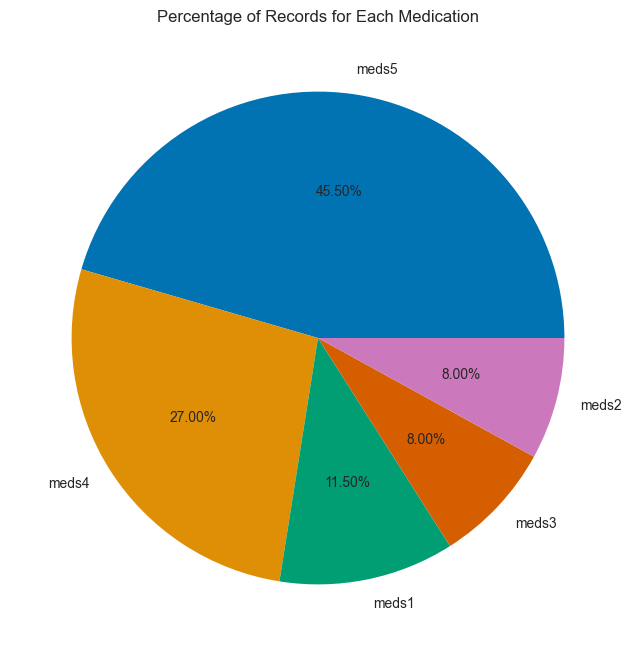

In [10]:
print("\n--- Balance check ---")
plt.figure(figsize=(10, 8))
drug_counts_percentage = drug_counts / len(meds) * 100
drug_counts_percentage.plot(kind='pie', autopct='%.2f%%')
plt.title("Percentage of Records for Each Medication")
plt.ylabel("")  # Remove the y-label
plt.show()

## 2.7 Perform oversampling to balance the data

In [11]:
print("\n--- Resampling data to balance medication records ---")
# First, we need to convert object columns to numerical for the resampler to work
# We'll create a temporary dataframe for resampling
meds_temp = meds.copy()

# Create label encoders for object columns
label_encoders = {}
for column in meds_temp.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    meds_temp[column] = le.fit_transform(meds_temp[column])
    label_encoders[column] = le

# Define features and target for resampling
X_temp = meds_temp.drop('Medication', axis=1)
y_temp = meds_temp['Medication']

# Apply random oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_temp, y_temp)

# Create the resampled dataframe
meds_resampled = pd.DataFrame(X_resampled, columns=X_temp.columns)
meds_resampled['Medication'] = y_resampled

# Convert the encoded values back to original categories
for column, le in label_encoders.items():
    if column != 'Medication':  # Skip the target column
        meds_resampled[column] = le.inverse_transform(meds_resampled[column].astype(int))

print("Data resampling complete")
print(f"Original dataset shape: {meds.shape}")
print(f"Resampled dataset shape: {meds_resampled.shape}")


--- Resampling data to balance medication records ---
Data resampling complete
Original dataset shape: (200, 6)
Resampled dataset shape: (455, 6)


## 2.8 Confirm successful resampling


--- Confirmation of successful resampling ---
Medication
4    91
2    91
3    91
0    91
1    91
Name: count, dtype: int64


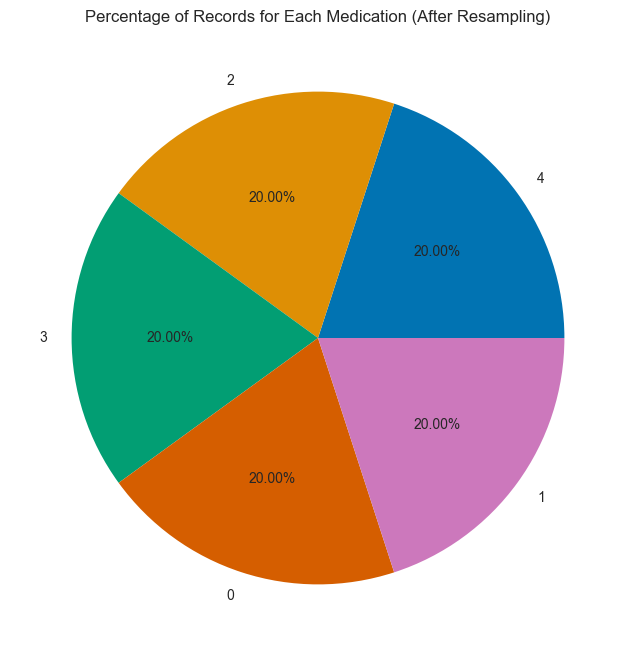

In [12]:
print("\n--- Confirmation of successful resampling ---")
resampled_drug_counts = meds_resampled['Medication'].value_counts()
print(resampled_drug_counts)

plt.figure(figsize=(10, 8))
resampled_drug_counts_percentage = resampled_drug_counts / len(meds_resampled) * 100
resampled_drug_counts_percentage.plot(kind='pie', autopct='%.2f%%')
plt.title("Percentage of Records for Each Medication (After Resampling)")
plt.ylabel("")  # Remove the y-label
plt.show()

## 2.9 Convert text values to numeric values

In [13]:
print("\n--- Converting text values to numeric values ---")
# Identify columns with text values
object_columns = meds_resampled.select_dtypes(include=['object']).columns
print(f"Columns with text values: {list(object_columns)}")

# Convert columns with only two unique text values to binary [0, 1]
# Convert columns with more than two unique text values to numeric [0, 1, 2, ..., n]
for col in object_columns:
    unique_values = meds_resampled[col].unique()
    n_unique = len(unique_values)
    print(f"Column {col} has {n_unique} unique values: {unique_values}")
    
    le = LabelEncoder()
    meds_resampled[col] = le.fit_transform(meds_resampled[col])
    
    # Map the encoded values to their original categories for reference
    value_mapping = {i: val for i, val in enumerate(le.classes_)}
    print(f"Mapping for {col}: {value_mapping}")

print("\nText to numeric conversion completed")


--- Converting text values to numeric values ---
Columns with text values: ['Gender', 'Blood_Presure', 'Cholesterol']
Column Gender has 2 unique values: ['Female' 'Male']
Mapping for Gender: {0: 'Female', 1: 'Male'}
Column Blood_Presure has 3 unique values: ['High' 'Low' 'Normal']
Mapping for Blood_Presure: {0: 'High', 1: 'Low', 2: 'Normal'}
Column Cholesterol has 2 unique values: ['High' 'Normal']
Mapping for Cholesterol: {0: 'High', 1: 'Normal'}

Text to numeric conversion completed


## 2.10 Confirm no more object columns

In [14]:
print("\n--- Confirmation of no more object columns ---")
object_columns_remaining = meds_resampled.select_dtypes(include=['object']).columns
print(f"Remaining object columns: {list(object_columns_remaining)}")
print(f"Data types:\n{meds_resampled.dtypes}")


--- Confirmation of no more object columns ---
Remaining object columns: []
Data types:
Age                int64
Gender             int64
Blood_Presure      int64
Cholesterol        int64
Ratio_Na_K       float64
Medication         int64
dtype: object


## 2.11 Determine correlation between Medication and other columns


--- Correlation between Medication and other columns ---


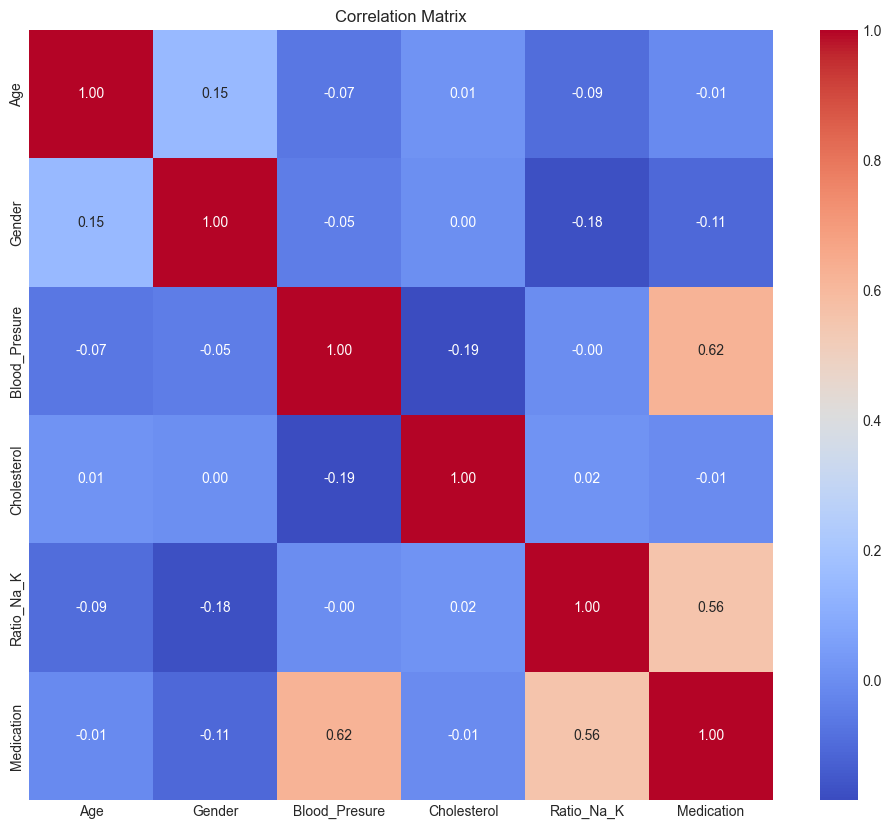

In [15]:
print("\n--- Correlation between Medication and other columns ---")
plt.figure(figsize=(12, 10))
correlation_matrix = meds_resampled.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 2.12 Deductions from correlation values

In [17]:
print("\n--- Deductions from correlation values ---")
# Get the correlations with the target variable 'Drug'
drug_correlations = correlation_matrix['Medication'].sort_values(ascending=False)
print(drug_correlations)

print("""
Deductions from the correlation values:
1. The features with the strongest correlation to the prescribed medication are Na_to_K and Age, 
   confirming our observations from the scatter plot.
2. The medical features like BP (blood pressure), Cholesterol, and Sex also show some correlation 
   with medication choice, though less strong than Na_to_K and Age.
3. These correlations suggest that doctors are likely considering multiple factors when 
   prescribing medications, with the sodium-potassium ratio and age being particularly influential.
""")


--- Deductions from correlation values ---
Medication       1.000000
Blood_Presure    0.620695
Ratio_Na_K       0.559481
Cholesterol     -0.006277
Age             -0.010612
Gender          -0.110059
Name: Medication, dtype: float64

Deductions from the correlation values:
1. The features with the strongest correlation to the prescribed medication are Na_to_K and Age, 
   confirming our observations from the scatter plot.
2. The medical features like BP (blood pressure), Cholesterol, and Sex also show some correlation 
   with medication choice, though less strong than Na_to_K and Age.
3. These correlations suggest that doctors are likely considering multiple factors when 
   prescribing medications, with the sodium-potassium ratio and age being particularly influential.



## 2.13 Define X and y and create training/testing datasets

In [18]:
print("\n--- Defining X and y and creating training/testing datasets ---")
X = meds_resampled.drop('Medication', axis=1)
y = meds_resampled['Medication']

# Split the data into training and testing sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display dimensions
print(f"X dimensions: {X.shape}")
print(f"y dimensions: {y.shape}")
print(f"X_train dimensions: {X_train.shape}")
print(f"X_test dimensions: {X_test.shape}")


--- Defining X and y and creating training/testing datasets ---
X dimensions: (455, 5)
y dimensions: (455,)
X_train dimensions: (364, 5)
X_test dimensions: (91, 5)


## 2.14 Train classifiers and determine the best model using k-fold cross-validation

In [19]:
print("\n--- Training classifiers with k-fold cross-validation ---")

# Define the classifiers
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=5, random_state=42)

# Define k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define the list of classifiers
classifiers = [
    ("K-Nearest Neighbors", knn),
    ("Decision Tree", dt),
    ("Random Forest", rf)
]

# Cross-validate each classifier and store results
results = []
for name, clf in classifiers:
    # Cross-validated accuracy
    cv_accuracy = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy')
    # Cross-validated F1 score (weighted average for multi-class)
    cv_f1 = cross_val_score(clf, X_train, y_train, cv=kf, scoring='f1_weighted')
    
    results.append({
        'Classifier': name,
        'Mean CV Accuracy': cv_accuracy.mean(),
        'Mean CV F1 Score': cv_f1.mean()
    })
    
    print(f"\n{name}:")
    print(f"  Cross-validated Training Accuracy: {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
    print(f"  Cross-validated F1 Score: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# Create a DataFrame for results
results_df = pd.DataFrame(results)
print("\nCross-validation results summary:")
print(results_df)

# Find the best model based on F1 score
best_model_idx = results_df['Mean CV F1 Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Classifier']
best_model = [clf for name, clf in classifiers if name == best_model_name][0]

print(f"\nBest model based on F1 score: {best_model_name}")


--- Training classifiers with k-fold cross-validation ---

K-Nearest Neighbors:
  Cross-validated Training Accuracy: 0.7940 ± 0.0343
  Cross-validated F1 Score: 0.7782 ± 0.0436

Decision Tree:
  Cross-validated Training Accuracy: 1.0000 ± 0.0000
  Cross-validated F1 Score: 1.0000 ± 0.0000

Random Forest:
  Cross-validated Training Accuracy: 0.9972 ± 0.0056
  Cross-validated F1 Score: 0.9973 ± 0.0055

Cross-validation results summary:
            Classifier  Mean CV Accuracy  Mean CV F1 Score
0  K-Nearest Neighbors          0.794026          0.778247
1        Decision Tree          1.000000          1.000000
2        Random Forest          0.997222          0.997256

Best model based on F1 score: Decision Tree


## 2.15 Use the best model to make predictions on test data

In [20]:
print("\n--- Testing the best model ---")
# Train the best model on the full training data
best_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Generate classification report
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)


--- Testing the best model ---
Test Accuracy: 0.9890

Confusion Matrix:
[[18  0  0  0  0]
 [ 0 19  0  0  0]
 [ 0  0 15  0  0]
 [ 0  0  0 19  1]
 [ 0  0  0  0 19]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        19
           2       1.00      1.00      1.00        15
           3       1.00      0.95      0.97        20
           4       0.95      1.00      0.97        19

    accuracy                           0.99        91
   macro avg       0.99      0.99      0.99        91
weighted avg       0.99      0.99      0.99        91



## 2.16 Discuss the selected model's metrics and scores

In [21]:
print("\n--- Discussion of the selected model's metrics and scores ---")
print(f"""
Model Performance Analysis:

1. Comparing Training and Testing Accuracy:
   - Training Accuracy (from cross-validation): {results_df.loc[best_model_idx, 'Mean CV Accuracy']:.4f}
   - Testing Accuracy: {test_accuracy:.4f}
   
   The difference between training and testing accuracy indicates how well the model generalizes to unseen data. 
   A small difference suggests good generalization, while a large difference might indicate overfitting.

2. Understanding the Precision, Recall and F1-scores:
   - Precision represents how many of the predicted positive cases are actually positive.
     It answers: "Of all patients predicted to respond well to a specific medication, how many actually do?"
   - Recall represents how many of the actual positive cases are correctly predicted.
     It answers: "Of all patients who would respond well to a specific medication, how many are correctly identified?"
   - F1-score is the harmonic mean of precision and recall, providing a balance between the two metrics.
     It's particularly useful when there's an uneven class distribution.
   
   In a healthcare context like medication recommendation, both precision and recall are important:
   - High precision means we're not prescribing medications to patients who won't benefit from them.
   - High recall means we're identifying most patients who would benefit from a particular medication.
   
   The F1-scores for each medication class show how well the model balances these concerns for each type of medication.
""")


--- Discussion of the selected model's metrics and scores ---

Model Performance Analysis:

1. Comparing Training and Testing Accuracy:
   - Training Accuracy (from cross-validation): 1.0000
   - Testing Accuracy: 0.9890

   The difference between training and testing accuracy indicates how well the model generalizes to unseen data. 
   A small difference suggests good generalization, while a large difference might indicate overfitting.

2. Understanding the Precision, Recall and F1-scores:
   - Precision represents how many of the predicted positive cases are actually positive.
     It answers: "Of all patients predicted to respond well to a specific medication, how many actually do?"
   - Recall represents how many of the actual positive cases are correctly predicted.
     It answers: "Of all patients who would respond well to a specific medication, how many are correctly identified?"
   - F1-score is the harmonic mean of precision and recall, providing a balance between the two met